# Stage 1: Data Understanding

This notebook validates the runtime data acquisition layer for Phase 1. It downloads data directly from Yahoo Finance, drops assets with more than 5% missing observations, forward-fills the remaining gaps, back-fills any leading gaps, inspects adjusted close prices and volume, and visualizes the sample asset universe.

## Objectives

- Use the `YahooFinanceProvider` directly at runtime.
- Download the sample universe: `HDFCBANK.NS`, `TCS.NS`, `GOLDBEES.NS`.
- Validate dates, adjusted close coverage, volume coverage, and missing values.
- Drop assets with more than 5% missing observations, then forward-fill and back-fill the remaining gaps.
- Produce in-memory outputs: `prices_df` and `volume_df`.
- Visualize price behavior and data completeness before moving to returns.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.data_pipeline.preprocess as preprocess_module
import src.data_pipeline as data_pipeline_module
importlib.reload(preprocess_module)
importlib.reload(data_pipeline_module)

from src.data_pipeline import SAMPLE_UNIVERSE, DataPreprocessor, MarketDataBundle, YahooFinanceProvider, build_data_inspection_table

In [2]:
symbols = list(SAMPLE_UNIVERSE)
start_date = "2019-01-01"
end_date = "2020-12-31"

provider = YahooFinanceProvider()
market_data = provider.get_market_data(symbols, start_date, end_date)

raw_prices_df = market_data.prices_df.copy()
raw_volume_df = market_data.volume_df.copy()

prices_df, price_quality_report = DataPreprocessor.handle_missing_values(raw_prices_df)
volume_df = raw_volume_df.reindex(columns=prices_df.columns)
dropped_assets = list(price_quality_report.dropped_asset_names)
cleaned_market_data = MarketDataBundle(
    prices_df=prices_df,
    volume_df=volume_df,
    raw_data=market_data.raw_data,
    price_field=market_data.price_field,
)
inspection_df = build_data_inspection_table(cleaned_market_data)

print(f"Price field used: {market_data.price_field}")
print(f"Raw price shape: {raw_prices_df.shape}")
print(f"Raw volume shape: {raw_volume_df.shape}")
print(f"Clean price shape: {prices_df.shape}")
print(f"Clean volume shape: {volume_df.shape}")
print(f"Dropped price assets (>5% missing): {price_quality_report.assets_dropped}")
if dropped_assets:
    print(", ".join(dropped_assets))
print(f"Price missing before cleaning: {price_quality_report.missing_before}")
print(f"Price missing after cleaning: {price_quality_report.missing_after}")

Price field used: Adj Close
Raw price shape: (493, 28)
Raw volume shape: (493, 28)
Clean price shape: (493, 28)
Clean volume shape: (493, 28)
Dropped price assets (>5% missing): 0
Price missing before cleaning: 0
Price missing after cleaning: 0


In [3]:
prices_df.head()

Ticker,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,1295.010742,623.916809,280.425446,491.097046,498.221802,28.177999,375.389374,504.392609,1607.500732,350.957001,...,94.748299,75.199860,496.196411,271.551208,402.755859,205.282013,1561.000366,556.562683,3878.702881,112.147346
2019-01-02,1306.105347,616.705994,274.413177,483.116333,497.075195,28.288500,370.109650,499.790161,1592.774170,351.777130,...,93.823151,73.413857,489.733887,266.384766,408.794220,201.065811,1577.817871,551.106201,3875.703857,111.769684
2019-01-03,1310.826172,604.671143,275.159210,481.097748,492.545990,28.470501,370.891754,495.868927,1596.165771,350.474579,...,90.856277,72.586662,483.691895,263.846924,405.124817,196.802750,1558.661987,535.007568,3773.105957,111.752510
2019-01-04,1308.512817,616.258301,283.014648,481.473236,496.874512,28.298000,364.634399,497.195496,1590.185913,352.356049,...,92.961807,73.658249,486.303467,269.783691,402.988129,200.316238,1539.711670,527.151611,3787.133545,111.392021
2019-01-07,1318.096313,634.012146,285.208893,482.646912,488.972321,28.224501,368.232422,497.946991,1593.086670,354.768127,...,94.333595,74.617043,489.003540,268.560089,400.201233,201.393753,1556.980469,532.105164,3798.936768,111.323372


In [4]:
volume_df.head()

Ticker,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,664707,12179223,6117146,1361809,1693785,897800,717468,6373440,807345,7759872,...,4496586,3961625,9746670,11837127,8487116,716275,1094883,815535,92921,4036542
2019-01-02,1233780,12386281,6218991,1243067,2087755,1030500,2270096,8134232,1598707,18243156,...,17436694,7876559,15628818,25559853,9656878,1081778,2100463,2576769,143828,8822139
2019-01-03,1636293,13228602,6230813,2086150,2709455,1521200,2809224,12771664,1182624,12884409,...,26599483,7942863,16288287,17548347,9479511,2096553,2611668,3558015,223538,9446080
2019-01-04,1202397,8381367,11361086,1651456,2036985,1355000,3077278,7287120,1454134,22896026,...,7395898,4017540,18516544,19514041,6228693,1213181,4280862,3926171,220079,6414073
2019-01-07,1074373,11735286,5511088,1168002,2712075,1115600,2344752,5387012,909032,12719847,...,12700566,3592512,12060290,14579399,4118235,871903,1856423,1885000,220371,5076276


In [5]:
inspection_df

,price_field,start_date,end_date,price_observations,volume_observations,missing_prices,missing_volume,dates_monotonic_increasing
symbol,,,,,,,,
ASIANPAINT.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
AXISBANK.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
BHARTIARTL.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
CIPLA.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
DRREDDY.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
GOLDBEES.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
HCLTECH.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
HDFCBANK.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True
HINDUNILVR.NS,Adj Close,2019-01-01,2020-12-30,493,493,0,0,True


In [6]:
prices_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
ASIANPAINT.NS,493.0,1630.626761,279.272344,1231.608154,1381.499268,1629.967041,1739.433105,2617.289062
AXISBANK.NS,493.0,615.953012,140.817623,301.889496,451.216003,668.309570,734.234253,818.362488
BHARTIARTL.NS,493.0,409.300387,89.360096,264.012421,329.934204,416.405060,490.370789,572.402222
CIPLA.NS,493.0,542.438243,114.270783,357.556427,445.359497,514.147339,615.394043,795.078735
DRREDDY.NS,493.0,656.290328,173.163178,479.992340,513.865479,558.143005,778.496338,1033.664185
GOLDBEES.NS,493.0,36.208115,6.671791,0.335500,30.007000,34.750000,42.689999,49.169998
HCLTECH.NS,493.0,472.685597,97.887055,320.840027,414.293213,438.137878,481.378510,751.570862
HDFCBANK.NS,493.0,541.090923,61.488140,363.573395,499.320648,537.474854,585.283386,682.818909
HINDUNILVR.NS,493.0,1807.656337,195.279772,1480.764038,1605.894165,1844.767944,1964.829102,2247.833496


In [7]:
volume_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
ASIANPAINT.NS,493.0,1.852172e+06,1.220837e+06,124919.0,1050985.0,1527660.0,2372909.0,11545923.0
AXISBANK.NS,493.0,1.889158e+07,1.517291e+07,965647.0,7851370.0,12419831.0,26230891.0,96186227.0
BHARTIARTL.NS,493.0,1.557733e+07,1.543169e+07,2033141.0,6727458.0,12005925.0,18550546.0,190329697.0
CIPLA.NS,493.0,4.925217e+06,5.087704e+06,179612.0,1753611.0,3215535.0,6263334.0,56895213.0
DRREDDY.NS,493.0,5.536829e+06,7.183794e+06,113015.0,2596265.0,3889695.0,5974940.0,109935390.0
GOLDBEES.NS,493.0,3.753765e+06,8.178789e+06,438600.0,1196300.0,2322978.0,4518700.0,166442200.0
HCLTECH.NS,493.0,5.280225e+06,4.034128e+06,303910.0,2911690.0,4090511.0,6325701.0,32312474.0
HDFCBANK.NS,493.0,2.091905e+07,1.459357e+07,1750082.0,10802584.0,16482688.0,26612674.0,108128700.0
HINDUNILVR.NS,493.0,2.591357e+06,8.526143e+06,85187.0,1224058.0,1679160.0,2487234.0,185669922.0


In [8]:
missing_summary = pd.DataFrame(
    {
        "price_missing_before": raw_prices_df.isna().sum(),
        "price_missing_after": prices_df.isna().sum(),
        "price_missing_before_ratio": raw_prices_df.isna().mean(),
        "price_missing_after_ratio": prices_df.isna().mean(),
    }
)
missing_summary.sort_values("price_missing_before_ratio", ascending=False)

,price_missing_before,price_missing_after,price_missing_before_ratio,price_missing_after_ratio
Ticker,,,,
ASIANPAINT.NS,0,0,0.0,0.0
AXISBANK.NS,0,0,0.0,0.0
BHARTIARTL.NS,0,0,0.0,0.0
CIPLA.NS,0,0,0.0,0.0
DRREDDY.NS,0,0,0.0,0.0
GOLDBEES.NS,0,0,0.0,0.0
HCLTECH.NS,0,0,0.0,0.0
HDFCBANK.NS,0,0,0.0,0.0
HINDUNILVR.NS,0,0,0.0,0.0


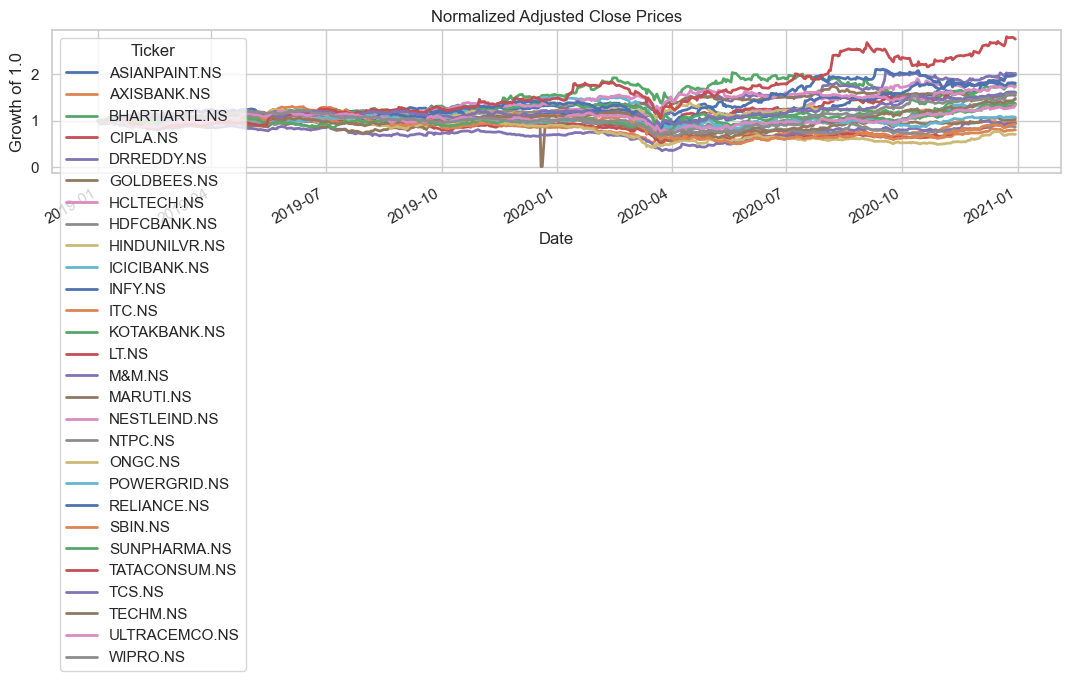

In [9]:
sns.set_theme(style="whitegrid")
normalized_prices = prices_df / prices_df.iloc[0]
ax = normalized_prices.plot(figsize=(11, 5), linewidth=2)
ax.set_title("Normalized Adjusted Close Prices")
ax.set_ylabel("Growth of 1.0")
ax.set_xlabel("Date")
plt.tight_layout()

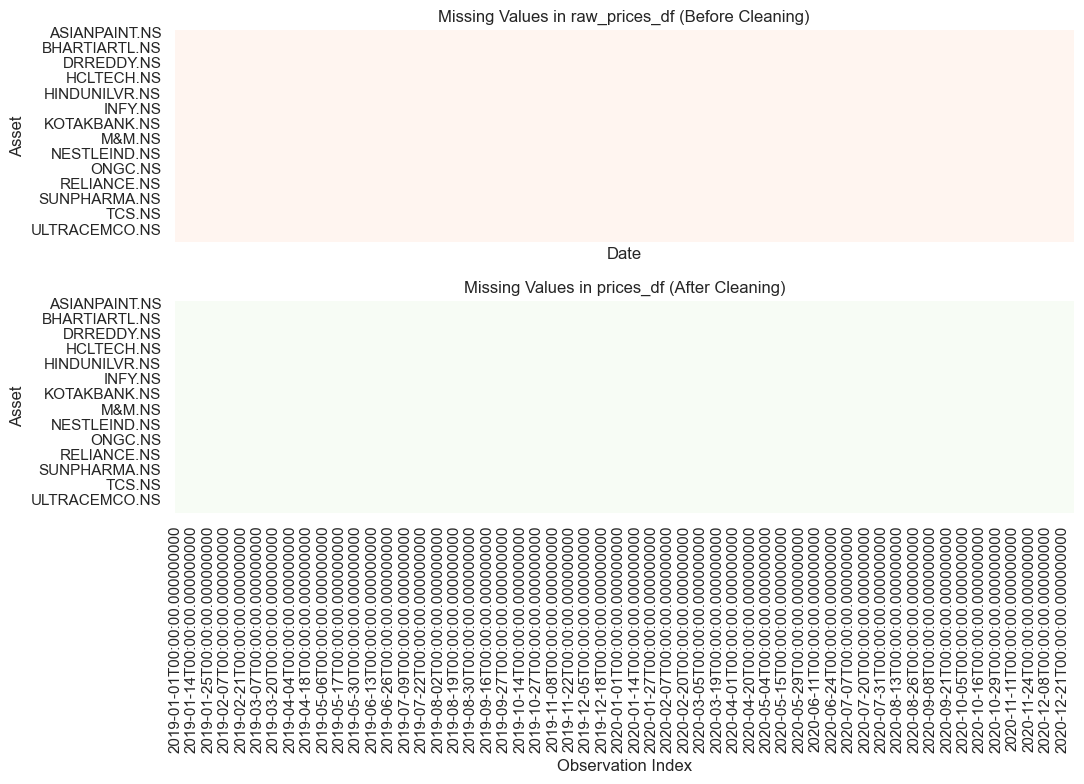

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
raw_prices_df.isna().astype(int).T.pipe(sns.heatmap, cmap="Reds", cbar=False, ax=axes[0])
axes[0].set_title("Missing Values in raw_prices_df (Before Cleaning)")
axes[0].set_ylabel("Asset")

prices_df.isna().astype(int).T.pipe(sns.heatmap, cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Missing Values in prices_df (After Cleaning)")
axes[1].set_ylabel("Asset")
axes[1].set_xlabel("Observation Index")
plt.tight_layout()

## Interpretation

- `prices_df` is the adjusted close panel used for downstream return calculations.
- `volume_df` helps validate tradability and data completeness before portfolio construction.
- Any missing-value clusters should be handled before returns are computed in Stage 2.
- This stage deliberately keeps all processing in memory and avoids persistent dataset storage.